# Kaggle Submit — Gemma4-E4B v2-fresh adapter on test.csv 10k (T4 x2, resumable)

**Purpose:** run the v2-fresh adapter_best (3.1ep finetune) + base over `/kaggle/input/competitions/astroclimb/test.csv` (10k rows) and write `submission.csv` (`id,same_figure,same_paper,related_papers,unrelated_papers` one-hot).

**Requirements:** `GPU T4 x2`, Internet ON, Secrets `HF_TOKEN` (write scope).

**Resumable by design:** every scored row streams to local staging jsonl; `submission/submission_progress.csv` (+raw) is re-uploaded to the HF repo every 200 rows, and local staging is deleted at each phase end - **Hugging Face is the ONLY store**. A dead session loses nothing: done ids reload from HF and are skipped. ~10k rows x ~5s = ~14h total, plan ~2 sessions (8h time guard each).

**Test format:** OLD competition style — `obj_1`/`obj_2` cells hold caption text or base64 PNG, decoded per side in-cell. No folders, no UUIDs, no external images.


In [1]:
# --- 0. Config (v2-fresh adapter_best 3.1ep, results to same repo) ---
MODEL_ID = "google/gemma-4-E4B-it"  # base id (v2-fresh adapter attached from ADAPTER_SUBFOLDER)
HF_REPO_ID = "ShivRamSaud/gemma4-e4b-qlora-astroclimb-v2-fresh"
ADAPTER_SUBFOLDER = "adapter_best"
TEST_CSV = "/kaggle/input/competitions/astroclimb/test.csv"
SUB_COLS = ["same_figure","same_paper","related_papers","unrelated_papers"]  # submission order
MAX_NEW_TOKENS = 32
HF_PUSH_EVERY = 200  # HF is the ONLY store; local files are upload staging, deleted after each push
TIME_BUDGET = 8*3600  # stop cleanly inside 9h session
OUT_DIR = "/kaggle/working/gemma_e4b_submit"
PROG_LOCAL = OUT_DIR + "/submission_progress.csv"
RAW_LOCAL = OUT_DIR + "/raw_test.jsonl"
HF_PROG = "submission/submission_progress.csv"
HF_RAW = "submission/raw_test.jsonl"
HF_FINAL = "submission/submission.csv"
import os; os.makedirs(OUT_DIR, exist_ok=True)
print(f'adapter={HF_REPO_ID}/{ADAPTER_SUBFOLDER} (best at 3.1ep)')
print(f'results -> {HF_REPO_ID}/submission/ (same repo)')
print(f'TEST={TEST_CSV}')


adapter=ShivRamSaud/gemma4-e4b-qlora-astroclimb-v2-fresh/adapter_best (best at 3.1ep)
results -> ShivRamSaud/gemma4-e4b-qlora-astroclimb-v2-fresh/submission/ (same repo)
TEST=/kaggle/input/competitions/astroclimb/test.csv


In [2]:
# --- 1. Setup (Kaggle T4 x2) ---
import os, json, time, re, gc, base64, sys, subprocess
from pathlib import Path
from io import BytesIO
import pandas as pd, numpy as np
import torch
from tqdm import tqdm
from PIL import Image
print(f"torch {torch.__version__} cuda {torch.cuda.is_available()}")
assert torch.cuda.is_available(), 'Enable GPU: Settings -> Accelerator -> GPU T4 x2'
assert torch.cuda.device_count() >= 2, 'Need 2xT4'
print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import importlib.metadata as _im
try:
    _ver = _im.version("transformers")
    from packaging import version as _pv
    _need = _pv.parse(_ver) < _pv.parse("5.15.1")
    print(f"transformers {_ver} need upgrade: {_need}")
except: _need=True; _ver='0.0.0'
if _need:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','git+https://github.com/huggingface/transformers.git','accelerate','peft>=0.15.0','bitsandbytes>=0.46.1'])
    print('installs OK')
    for m in list(sys.modules.keys()):
        if m.startswith("transformers"): del sys.modules[m]
    import importlib as _il; _il.invalidate_caches()
import transformers; print(f'transformers {transformers.__version__}')


torch 2.10.0+cu128 cuda True
['Tesla T4', 'Tesla T4']
transformers 5.0.0 need upgrade: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.7 MB/s eta 0:00:00
installs OK
transformers 5.17.0.dev0


In [3]:
# --- 1b. HF Login (read merged + write progress/submission) ---
from huggingface_hub import login
import os
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
assert HF_TOKEN, 'Add HF_TOKEN (write) to Kaggle Secrets'
login(token=HF_TOKEN)
print('HF login OK')


HF login OK


test rows=10000
id column: id
OLD-format cols (base64 in-cell, no folders): True
OLD-format cols (base64 in-cell, no folders): True
_o2_img  False  True 
_o1_img              
False     3000   4000
True         0   3000
row 0 id=0 obj_1[:100]='Box plot statistic for CH3OH, H2CO, and NH3 abundances in comets. Starting from the left, we show th' | obj_2 decoded size=(2066, 1209) mode=RGB


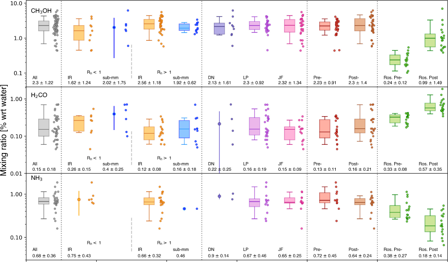

row 1 id=1 obj_1[:100]='Example of an uncorrected LXD spectrum, reflected continuum, and thermally corrected data.' | obj_2 decoded size=(1018, 638) mode=RGB


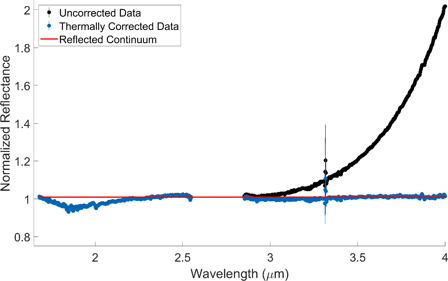

row 2 id=2 obj_1[:100]='Experimental rotational spectrum of 2-methoxyethanol (black) overlaid with the simulated spectrum of' | obj_2 decoded size=(1597, 1031) mode=RGB


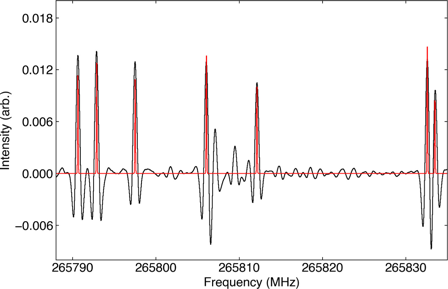

cells=20000 images_ok=10000 images_bad=0 captions=10000 empty=0
FULL DECODE AUDIT OK - 10000 images decode, 10000 captions detected, 0 empty (skipped+logged), 10k rows accounted


In [4]:
# --- 2. Test data (10k) + format detect per row ---
from pathlib import Path
from PIL import Image
from io import BytesIO
import base64
assert Path(TEST_CSV).exists(), f'test missing: {TEST_CSV}'
test = pd.read_csv(TEST_CSV)
print(f'test rows={len(test)}')
ID_COL = 'id' if 'id' in test.columns else test.columns[0]
print(f'id column: {ID_COL}')
OLD_FMT = {'obj_1','obj_2'} <= set(test.columns)
print(f'OLD-format cols (base64 in-cell, no folders): {OLD_FMT}')
print(f'OLD-format cols (base64 in-cell, no folders): {OLD_FMT}')
assert OLD_FMT, 'test.csv must have obj_1/obj_2 columns!'
assert 'label' not in test.columns and 'label_name' not in test.columns, 'test must be unlabeled - the model generates the labels!'
def is_image_str(s):
    if not isinstance(s, str) or len(s) < 200: return False
    return s.strip().startswith('iVBORw0KGgo')
# --- test inventory + FULL decode audit (every image cell must decode) ---
test['_o1_img'] = test['obj_1'].apply(is_image_str)
test['_o2_img'] = test['obj_2'].apply(is_image_str)
print(pd.crosstab(test['_o1_img'], test['_o2_img']))
from IPython.display import display as _display
_shown = 0
for _i, _r in test.iterrows():
    if _shown >= 3: break
    if _r['_o2_img']:
        _im = Image.open(BytesIO(base64.b64decode(_r['obj_2']))).convert('RGB')
        print(f"row {_i} id={_r[ID_COL]} obj_1[:100]={str(_r['obj_1'])[:100]!r} | obj_2 decoded size={_im.size} mode={_im.mode}")
        _th = _im.copy(); _th.thumbnail((448,448)); _display(_th)
        _shown += 1
assert _shown > 0, 'no decodable test images found!'
# full audit: decode EVERY image cell, classify EVERY cell, totals must meet 10k
_n_img_ok=_n_img_bad=_n_txt=_n_empty=0; _bad=[]
for _i, _r in test.iterrows():
    for _cc in ['obj_1','obj_2']:
        _s=_r[_cc]
        if pd.isna(_s) or (isinstance(_s,str) and len(_s.strip())==0):
            _n_empty+=1; _bad.append((_i,_cc,'empty'))
        elif is_image_str(_s):
            try:
                _d=Image.open(BytesIO(base64.b64decode(_s))).convert('RGB'); _d.load(); _n_img_ok+=1; del _d
            except Exception as _e:
                _n_img_bad+=1; _bad.append((_i,_cc,f'decode_fail:{_e}'))
        else: _n_txt+=1
print(f'cells={len(test)*2} images_ok={_n_img_ok} images_bad={_n_img_bad} captions={_n_txt} empty={_n_empty}')
assert _n_img_bad==0, f'{_n_img_bad} UNDECODABLE images, e.g. {_bad[:5]}'
assert _n_img_ok+_n_txt+_n_empty==2*len(test)==20000 and len(test)==10000, 'row/cell count mismatch!'
print(f'FULL DECODE AUDIT OK - {_n_img_ok} images decode, {_n_txt} captions detected, {_n_empty} empty (skipped+logged), 10k rows accounted')
test.drop(columns=['_o1_img','_o2_img'], inplace=True)


In [5]:
# --- 3. Builders (dual-format test reader, same prompt contract) ---
SYSTEM_PROMPT = 'You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.\n\nClasses:\n- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.\n- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.\n- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but style/authors differ.\n- unrelated_papers: No clear link. Different topics, instruments, scales, or writing/visual style with no overlap.\n\nBase your decision only on visual and textual content. Do not assume same_figure is impossible for any pair type - judge from alignment.\nOutput ONLY the lowercase label (e.g., related_papers), no explanation, no punctuation. Choose exactly one of: same_figure, same_paper, related_papers, unrelated_papers.'
def side_old(row, col, name):
    s=row[col]
    if pd.isna(s) or (isinstance(s, str) and len(s.strip()) == 0):
        return {'name':name,'is_img':False,'text':'','missing':True}  # empty cell -> skip row, never score a guess
    if is_image_str(s):
        try: im=Image.open(BytesIO(base64.b64decode(s))).convert('RGB')
        except: return {'name':name,'is_img':False,'text':'','missing':True}
        return {'name':name,'is_img':True,'pil':im,'missing':False}
    return {'name':name,'is_img':False,'text':str(s)[:2000],'missing':False}
def build_messages_test(row):
    parts=[side_old(row,'obj_1','Object A'), side_old(row,'obj_2','Object B')]
    if any(p.get('missing') for p in parts): return None
    content=[{"type":"text","text": SYSTEM_PROMPT+"\n"}]
    for p in parts:
        if p["is_img"]:
            im=p['pil'].copy(); im.thumbnail((448,448))
            content.append({"type":"image","image":im})
    for p in parts:
        if not p["is_img"]: content.append({"type":"text","text":"\n"+p["name"]+" (caption): "+p["text"]})
        else: content.append({"type":"text","text":"\n"+p["name"]+": [Figure image]"})
    content.append({"type":"text","text":"\nAnswer with one label:"})
    return [{"role":"user","content":content}]
import re
label_pattern = re.compile(r"(same_figure|same_paper|related_papers|unrelated_papers)", re.IGNORECASE)
def parse_label(text):
    m=label_pattern.search(str(text).lower()); return m.group(1).lower() if m else 'unrelated_papers'
_d0=build_messages_test(test.iloc[0])
print('demo built:', _d0 is not None, '| parts:', len(_d0[0]['content']) if _d0 else 0)


demo built: True | parts: 5


In [6]:
# --- 4. Model: base 4-bit + v2-fresh adapter_best (3.1ep) ---
from transformers import AutoProcessor
try:
    from transformers import BitsAndBytesConfig
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'bitsandbytes>=0.46.1'])
    from transformers import BitsAndBytesConfig
try:
    from peft import PeftModel
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'peft>=0.15.0'])
    from peft import PeftModel
import torch
try: processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side='left', trust_remote_code=True)
except TypeError: processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
print(f'Processor: {type(processor).__name__} (from base)')
try:
    from transformers import AutoModelForMultimodalLM as ModelClass; print('Using AutoModelForMultimodalLM')
except:
    from transformers import AutoModelForImageTextToText as ModelClass; print('Using AutoModelForImageTextToText')
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
base = ModelClass.from_pretrained(MODEL_ID, device_map='auto', max_memory={0:'14GB',1:'14GB'}, quantization_config=bnb, trust_remote_code=True)
print(f'Base loaded 4-bit: {type(base).__name__}')
import peft.tuners.lora.model as _lora_model
if not getattr(_lora_model.LoraModel._create_and_replace, '_is_patched', False):
    _orig_cnr = _lora_model.LoraModel._create_and_replace
    def _patched_cnr(self, lora_config, adapter_name, target, *args, **kwargs):
        if 'Gemma4ClippableLinear' in str(type(target)): return
        try:
            return _orig_cnr(self, lora_config, adapter_name, target, *args, **kwargs)
        except ValueError as e:
            if 'Gemma4ClippableLinear' in str(e): return
            raise
    _lora_model.LoraModel._create_and_replace = _patched_cnr
    _lora_model.LoraModel._create_and_replace._is_patched = True
    print('Patched peft for Gemma4ClippableLinear')
else:
    print('peft already patched')
model = PeftModel.from_pretrained(base, HF_REPO_ID, subfolder=ADAPTER_SUBFOLDER)
print(f'Adapter attached: {model.active_adapter} (from {HF_REPO_ID}/{ADAPTER_SUBFOLDER})')
model.eval()
print('Has generate: ' + str(hasattr(model, 'generate')))
try: _DEV = model.device
except: _DEV = torch.device('cuda:0')
# 2-sample check
for _i in [0,1]:
    _r=test.iloc[_i]; _m=build_messages_test(_r)
    assert _m is not None, f'demo row {_i} failed to build!'
    _t=processor.apply_chat_template(_m, tokenize=False, add_generation_prompt=True)
    _im=[p['image'] for t in _m for p in t['content'] if p.get('type')=='image'] or None
    _in=processor(text=[_t], images=_im, padding=True, return_tensors='pt')
    _in={k:(v.to(_DEV) if hasattr(v,'to') else v) for k,v in _in.items()}
    if 'pixel_values' in _in: _in['pixel_values']=_in['pixel_values'].to(torch.bfloat16)
    _L=_in['input_ids'].shape[1]
    with torch.no_grad(): _o=model.generate(**_in, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    _dec=processor.batch_decode(_o[:,_L:], skip_special_tokens=True)[0]
    print(f'sample {_i} id={_r[ID_COL]} raw={_dec.strip()[:60]!r} pred={parse_label(_dec)}')
    del _in,_o; torch.cuda.empty_cache()
print('Generate check OK')


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

...

Base loaded 4-bit: Gemma4ForConditionalGeneration
Patched peft for Gemma4ClippableLinear


adapter_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['monteclora_config', 'velora_config'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


adapter_best/adapter_model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Adapter attached: default (from ShivRamSaud/gemma4-e4b-qlora-astroclimb-v2-fresh/adapter_best)
Has generate: True
sample 0 id=0 raw='same_figure' pred=same_figure
sample 1 id=1 raw='same_figure' pred=same_figure
Generate check OK


In [7]:
# --- 5. Inference 10k: resume from HF progress, stream local + push HF ---
import time, json
from tqdm import tqdm
from huggingface_hub import HfApi, hf_hub_download
api=HfApi(); api.create_repo(repo_id=HF_REPO_ID, private=True, exist_ok=True)
# HF push with retry: transient 503s must NEVER kill the inference loop
def _hf_push(local, remote, msg, tries=4):
    import time as _t
    for _a in range(tries):
        try:
            api.upload_file(path_or_fileobj=local, path_in_repo=remote, repo_id=HF_REPO_ID, commit_message=msg)
            return True
        except Exception as e:
            print(f'push {remote} attempt {_a+1}/{tries} failed: {str(e)[:160]}')
            _t.sleep(45)
    return False
T_END=time.time()+TIME_BUDGET
# resume: load already-scored ids from HF progress file (if any)
done={}
for _ra in range(4):
    try:
        _pp=hf_hub_download(repo_id=HF_REPO_ID, filename=HF_PROG, repo_type='model')
        _pd=pd.read_csv(_pp)
        done=dict(zip(_pd['id'].astype(str), _pd['pred']))
        print(f'resumed {len(done)} rows from HF {HF_PROG}')
        break
    except Exception as e:
        import time as _t2
        if '404' in str(e) or 'Entry Not Found' in str(e):
            print('no HF progress file yet - starting fresh')
            break
        print(f'progress download attempt {_ra+1}/4 failed: {str(e)[:160]}')
        _t2.sleep(30)
else:
    print('WARNING: could not reach HF progress file - starting fresh; already-pushed rows will be RESCORED (wasteful but harmless)')
preds=dict(done)  # id(str) -> pred (all scored rows)
skipped=[]; n_oom=0; n_parse=0; t0=time.time(); n_new=0
_rawf=open(RAW_LOCAL,'a')
for idx in tqdm(range(len(test))):
    if time.time()>T_END: print(f'TIME GUARD at {idx}/{len(test)} - stopping clean, progress safe'); break
    row=test.iloc[idx]; _id=str(row[ID_COL])
    if _id in preds: continue  # resume skip
    msgs=build_messages_test(row)
    if msgs is None: skipped.append({'idx':int(idx),'id':_id,'reason':'unbuildable_input'}); preds[_id]='unrelated_papers'; continue
    text=processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    images=[p['image'] for t in msgs for p in t['content'] if p.get('type')=='image'] or None
    inputs=processor(text=[text], images=images, padding=True, return_tensors='pt')
    inputs={k:(v.to(_DEV) if hasattr(v,'to') else v) for k,v in inputs.items()}
    if 'pixel_values' in inputs: inputs['pixel_values']=inputs['pixel_values'].to(torch.bfloat16)
    L=inputs['input_ids'].shape[1]
    try:
        with torch.no_grad(): out=model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    except RuntimeError as e:
        if 'out of memory' not in str(e).lower(): raise
        torch.cuda.empty_cache(); gc.collect()
        try:
            with torch.no_grad(): out=model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
        except: decoded=''; n_oom+=1; pred='unrelated_papers'
        else: decoded=processor.batch_decode(out[:,L:], skip_special_tokens=True)[0]; pred=parse_label(decoded)
    else: decoded=processor.batch_decode(out[:,L:], skip_special_tokens=True)[0]; pred=parse_label(decoded)
    if pred=='unrelated_papers' and 'unrelated_papers' not in str(decoded).lower(): n_parse+=1
    preds[_id]=pred; n_new+=1
    _rawf.write(json.dumps({"id":_id,"pred":pred,"raw":decoded})+"\n"); _rawf.flush()
    del inputs
    if idx%50==0: torch.cuda.empty_cache()
    if n_new%HF_PUSH_EVERY==0:
        pd.DataFrame([{'id':k,'pred':v} for k,v in preds.items()]).to_csv(PROG_LOCAL,index=False)
        _ok1=_hf_push(PROG_LOCAL, HF_PROG, f'progress {len(preds)}/{len(test)}')
        _ok2=_hf_push(RAW_LOCAL, HF_RAW, f'raw {len(preds)}/{len(test)}')
        print(f'progress {len(preds)}/{len(test)} pushed={_ok1 and _ok2} elapsed {(time.time()-t0)/3600:.2f}h', flush=True)
_rawf.close()
pd.DataFrame([{'id':k,'pred':v} for k,v in preds.items()]).to_csv(PROG_LOCAL,index=False)
_okf1=_hf_push(PROG_LOCAL, HF_PROG, f'progress final {len(preds)}/{len(test)}')
_okf2=_hf_push(RAW_LOCAL, HF_RAW, 'raw final loop-end')
if _okf1 and _okf2:
    for _f in [PROG_LOCAL, RAW_LOCAL]:
        try: os.remove(_f)
        except: pass
    print('final progress pushed; local staging deleted - HF is source of truth')
else:
    print(f'FINAL PUSH INCOMPLETE - local staging kept at {OUT_DIR}; download it from Kaggle output before closing the session!')
print(f'LOOP DONE scored_total={len(preds)}/{len(test)} new_this_session={n_new} skipped={len(skipped)} oom={n_oom} parse_fb={n_parse} elapsed={(time.time()-t0)/3600:.2f}h')


submission_progress.csv: 0.00B [00:00, ?B/s]

resumed 200 rows from HF submission/submission_progress.csv


  4%|▍         | 399/10000 [15:20<12:41:21,  4.76s/it]

progress 400/10000 pushed=True elapsed 0.26h


  6%|▌         | 599/10000 [30:54<11:29:07,  4.40s/it]

...

progress 5600/10000 pushed=True elapsed 7.50h


 58%|█████▊    | 5799/10000 [7:45:42<5:40:14,  4.86s/it]

progress 5800/10000 pushed=True elapsed 7.76h


 60%|█████▉    | 5979/10000 [8:00:03<5:22:50,  4.82s/it]


TIME GUARD at 5979/10000 - stopping clean, progress safe
final progress pushed; local staging deleted - HF is source of truth
LOOP DONE scored_total=5979/10000 new_this_session=5779 skipped=0 oom=0 parse_fb=0 elapsed=8.00h


In [8]:
# --- 6. Assemble submission.csv (all 10k ids, one-hot, test order) ---
from huggingface_hub import HfApi, hf_hub_download
api=HfApi()
try:
    _pp=hf_hub_download(repo_id=HF_REPO_ID, filename=HF_PROG, repo_type='model')
    _scored=pd.read_csv(_pp); print(f'scored rows from HF: {len(_scored)}')
except Exception as e:
    _scored=pd.read_csv(PROG_LOCAL) if os.path.exists(PROG_LOCAL) else (_ for _ in ()).throw(RuntimeError(f'no HF progress ({e}) AND no local staging - nothing to assemble'))
    print(f'HF download failed ({e}) - local staging fallback: {len(_scored)}')
preds=dict(zip(_scored['id'].astype(str), _scored['pred']))
full=pd.DataFrame({'id':test[ID_COL].astype(str)})
full['pred']=full['id'].map(preds)
_missing=full['pred'].isna().sum()
print(f'mapped {len(full)-_missing}/{len(full)} (missing={_missing})')
assert _missing==0, f'{_missing} ids unscored - run another session to resume (progress is on HF)'
for c in SUB_COLS: full[c]=(full['pred']==c).astype(int)
assert ((full[SUB_COLS].sum(axis=1))==1).all(), 'rows not one-hot!'
sub=full[['id']+SUB_COLS]
sub.to_csv(os.path.join(OUT_DIR,'submission.csv'),index=False)
print(sub.head(3).to_string()); print(sub[SUB_COLS].sum().to_dict())
_oks=_hf_push(os.path.join(OUT_DIR,'submission.csv'), HF_FINAL, 'submission 10k from v2-fresh adapter_best 3.1ep')
_okr=_hf_push(RAW_LOCAL, HF_RAW, 'raw final') if os.path.exists(RAW_LOCAL) else True
if _oks:
    print(f'submission.csv pushed -> {HF_REPO_ID}/{HF_FINAL}')
    try: os.remove(os.path.join(OUT_DIR,'submission.csv')); print('local submission.csv deleted - HF copy is the deliverable')
    except: pass
else:
    print(f'SUBMISSION PUSH FAILED - download submission.csv from Kaggle output ({OUT_DIR}) and upload manually!')
try: os.remove(os.path.join(OUT_DIR,'submission.csv')); print('local submission.csv deleted - HF copy is the deliverable')
except: pass


submission_progress.csv: 0.00B [00:00, ?B/s]

scored rows from HF: 5979
mapped 5979/10000 (missing=4021)


AssertionError: 4021 ids unscored - run another session to resume (progress is on HF)

In [ ]:
# --- 7. Summary ---
print(f"test={len(test)} scored={len(preds)} skipped={len(skipped)} oom={n_oom} parse_fb={n_parse}")
print(f"pred dist: {pd.Series(list(preds.values())).value_counts().to_dict()}")
print(f"files live ONLY in {HF_REPO_ID}: {HF_PROG} + {HF_RAW} + {HF_FINAL} (local staging deleted)")
print('Next: download submission.csv from the HF repo -> upload to competition')
